# 🏠 Real Estate Investment Advisor
## Predicting Property Profitability & Future Value
**Domain:** Real Estate / Investment / Financial Analytics

Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, XGBRegressor

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models.signature import infer_signature

import joblib

Load Dataset

In [3]:
df = pd.read_csv('dataset/india_housing_prices.csv')

In [4]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (250000, 23)


In [5]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [7]:
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


Missing Values

In [8]:
print(df.isnull().sum())

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [9]:
print(f'\nTotal Missing: {df.isnull().sum().sum()}')
print(f'\nDuplicate Rows: {df.duplicated().sum()}')


Total Missing: 0

Duplicate Rows: 0


Data Preprocessing

In [10]:
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Shape after removing duplicates: (250000, 23)


Handle Missing Values

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print('Missing values after imputation:', df.isnull().sum().sum())

Missing values after imputation: 0


Feature Engineering

In [12]:
if 'Age_of_Property' not in df.columns:
    df['Age_of_Property'] = 2025 - df['Year_Built']

if 'Price_per_SqFt' not in df.columns:
    df['Price_per_SqFt'] = df['Price_in_Lakhs'] / df['Size_in_SqFt']

In [13]:
# Amenity Count
df['Amenity_Count'] = df['Amenities'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) else 0
)

In [14]:
# Transport Score
transport_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Transport_Score'] = df['Public_Transport_Accessibility'].map(transport_map).fillna(2)

In [15]:
# Infrastructure Score
df['Infrastructure_Score'] = (
    df['Nearby_Schools'] * 0.3 +
    df['Nearby_Hospitals'] * 0.3 +
    df['Transport_Score'] * 0.4
)

In [16]:
# Parking and Security binary
df['Has_Parking']  = df['Parking_Space'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
df['Has_Security'] = df['Security'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

In [17]:
# Floor Ratio
df['Floor_Ratio'] = df['Floor_No'] / df['Total_Floors'].replace(0, 1)

In [18]:
df[['Age_of_Property','Amenity_Count','Infrastructure_Score','Has_Parking','Has_Security','Floor_Ratio']].head()

,Age_of_Property,Amenity_Count,Infrastructure_Score,Has_Parking,Has_Security,Floor_Ratio
0,35,5,5.1,0,0,22.000000
1,17,5,3.1,0,1,1.050000
2,28,4,5.5,1,0,0.703704
3,34,5,4.8,1,1,0.807692
4,23,5,4.3,0,1,1.500000


Create Target Variables

In [19]:
# Regression target: Future Price in 5 years at 8% annual growth
GROWTH_RATE = 0.08
YEARS = 5
df['Future_Price_5Y'] = df['Price_in_Lakhs'] * ((1 + GROWTH_RATE) ** YEARS)

In [20]:
# Classification target: Good Investment
city_median_price     = df.groupby('City')['Price_in_Lakhs'].transform('median')
overall_ppsqft_median = df['Price_per_SqFt'].median()

In [21]:
df['Good_Investment'] = (
    (df['Price_in_Lakhs'] <= city_median_price) &
    (df['Price_per_SqFt'] <= overall_ppsqft_median) &
    (df['BHK'] >= 2)
).astype(int)

print(df['Good_Investment'].value_counts())
print(f'Positive rate: {df["Good_Investment"].mean():.2%}')

Good_Investment
0    170288
1     79712
Name: count, dtype: int64
Positive rate: 31.88%


Encode Categorical Features

In [22]:
le = LabelEncoder()
encode_cols = ['Furnished_Status', 'Facing', 'Owner_Type', 'Availability_Status', 'Property_Type']
for col in encode_cols:
    if col in df.columns:
        df[col + '_Enc'] = le.fit_transform(df[col].astype(str))

df['State_Enc'] = le.fit_transform(df['State'].astype(str))
df['City_Enc']  = le.fit_transform(df['City'].astype(str))

Outlier Removal using IQR

In [23]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

pre_shape = df.shape
for col in ['Price_in_Lakhs', 'Price_per_SqFt', 'Size_in_SqFt']:
    df = remove_outliers_iqr(df, col)
df.reset_index(drop=True, inplace=True)

print(f'Before: {pre_shape}, After: {df.shape}')

Before: (250000, 38), After: (229980, 38)


In [24]:
os.makedirs('dataset', exist_ok=True)
df.to_csv('dataset/processed_housing.csv', index=False)
print('Processed dataset saved')

Processed dataset saved


Exploratory Data Analysis (EDA)

Q1 & Q2: Distribution of Prices and Sizes

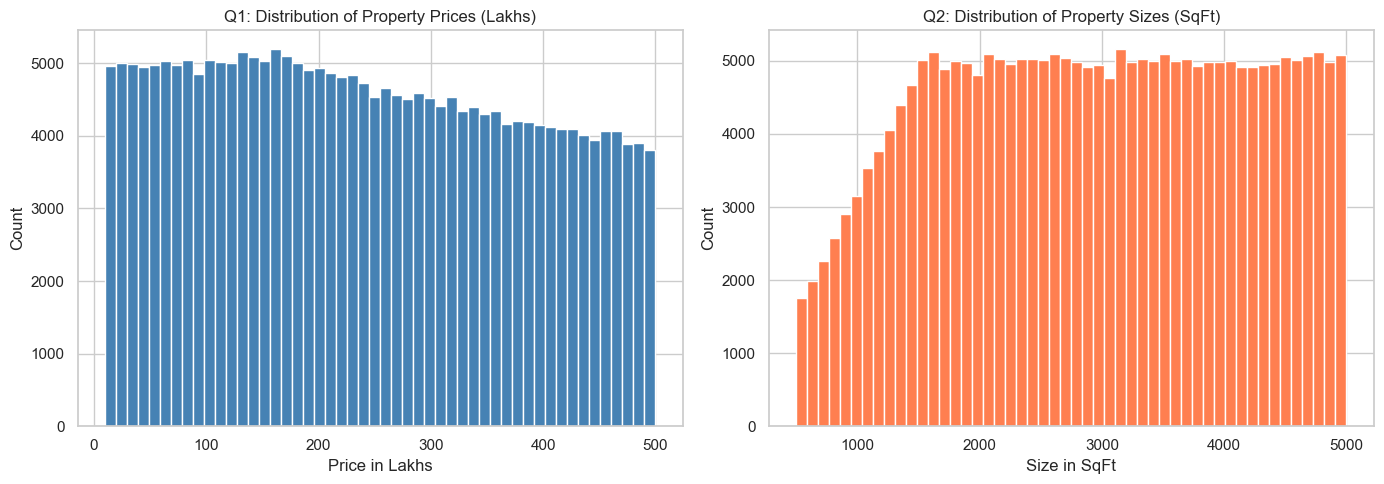

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Price_in_Lakhs'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Q1: Distribution of Property Prices (Lakhs)')
axes[0].set_xlabel('Price in Lakhs'); axes[0].set_ylabel('Count')

axes[1].hist(df['Size_in_SqFt'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Q2: Distribution of Property Sizes (SqFt)')
axes[1].set_xlabel('Size in SqFt'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

Q3: Price per SqFt by Property Type

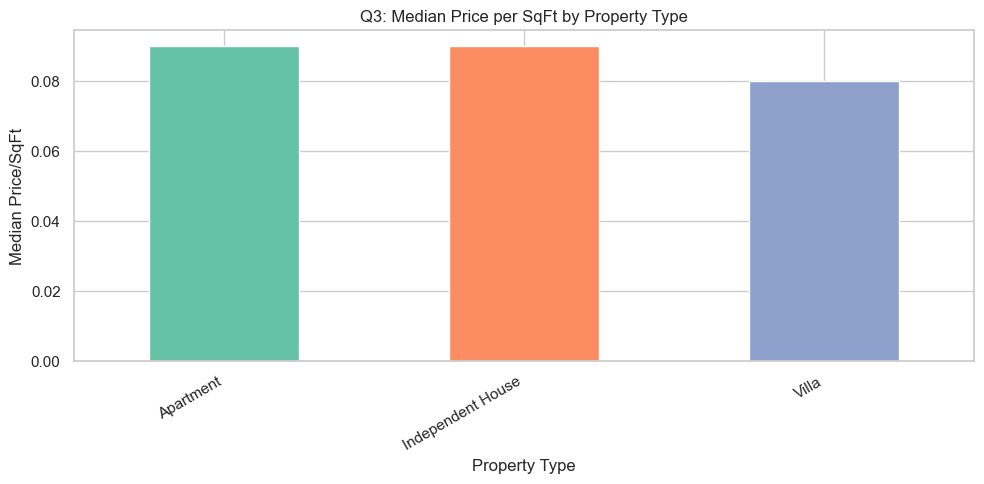

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('Property_Type')['Price_per_SqFt'].median().sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=sns.color_palette('Set2', 10), edgecolor='white'
)
ax.set_title('Q3: Median Price per SqFt by Property Type')
ax.set_xlabel('Property Type'); ax.set_ylabel('Median Price/SqFt')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); 
plt.show()

Q4: Size vs Price scatter

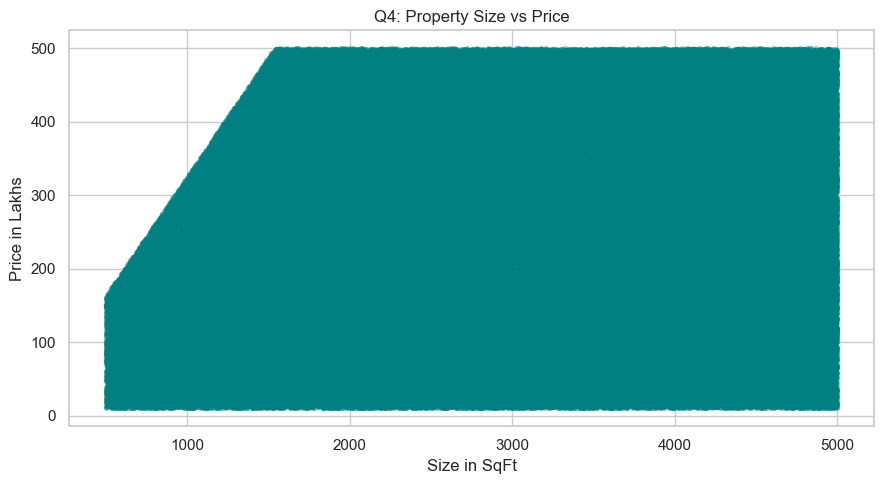

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Size_in_SqFt'], df['Price_in_Lakhs'], alpha=0.3, color='teal', s=8)
ax.set_title('Q4: Property Size vs Price')
ax.set_xlabel('Size in SqFt'); ax.set_ylabel('Price in Lakhs')
plt.tight_layout(); 
plt.show()

Q5: Outliers in Price/SqFt and Size — Boxplots

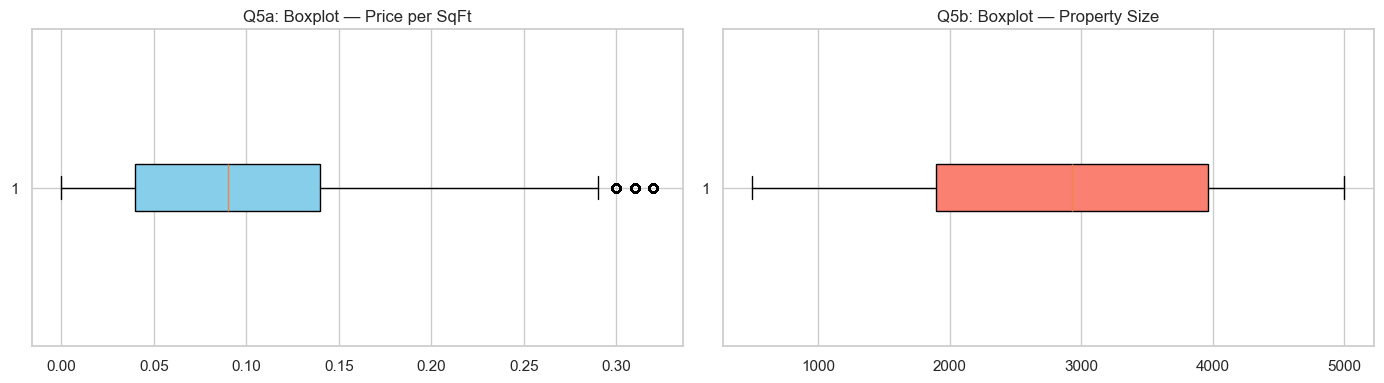

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].boxplot(df['Price_per_SqFt'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='skyblue'))
axes[0].set_title('Q5a: Boxplot — Price per SqFt')
axes[1].boxplot(df['Size_in_SqFt'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='salmon'))
axes[1].set_title('Q5b: Boxplot — Property Size')
plt.tight_layout(); 
plt.show()

Q6: Avg Price/SqFt by State

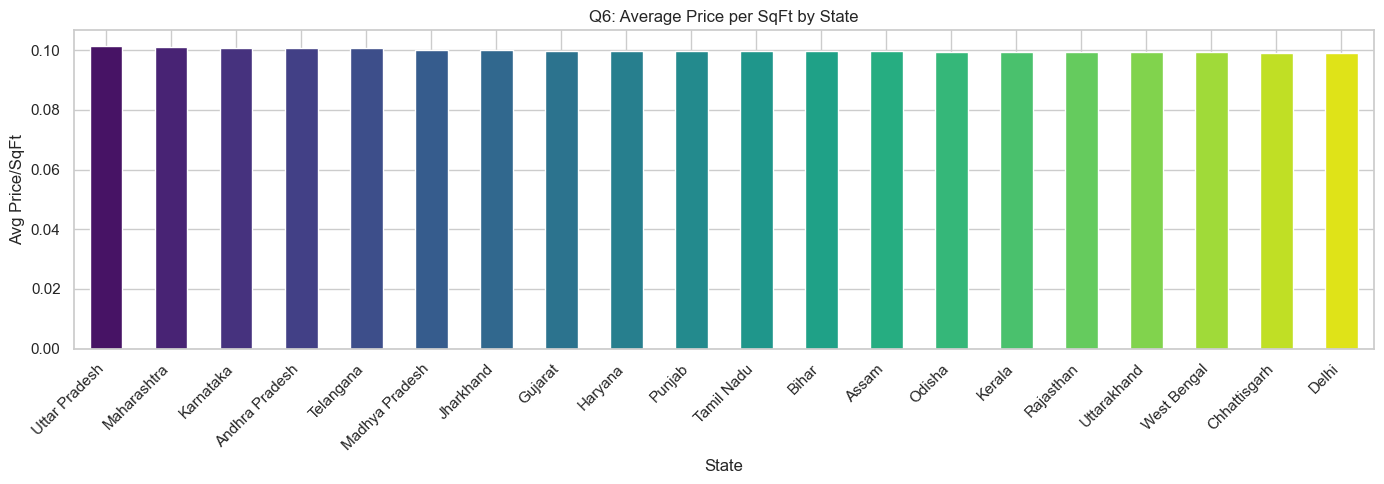

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
df.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=sns.color_palette('viridis', 20)
)
ax.set_title('Q6: Average Price per SqFt by State')
ax.set_xlabel('State'); ax.set_ylabel('Avg Price/SqFt')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); 
plt.show()

Q7: Average property price by City (Top 15)

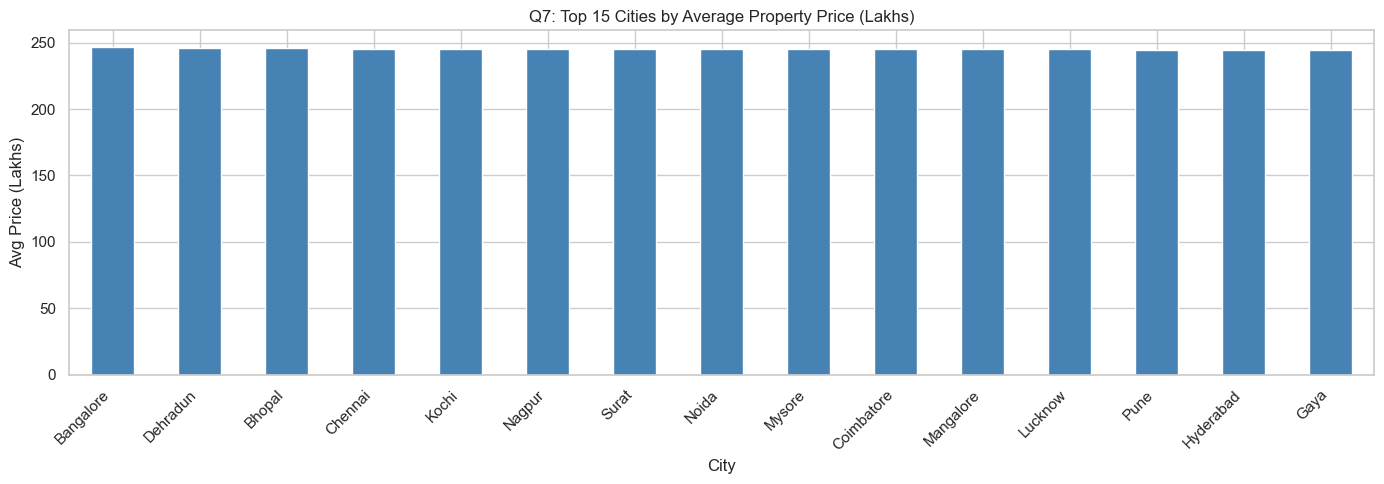

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))
df.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(15).plot(
    kind='bar', ax=ax, color='steelblue'
)
ax.set_title('Q7: Top 15 Cities by Average Property Price (Lakhs)')
ax.set_xlabel('City'); ax.set_ylabel('Avg Price (Lakhs)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); 
plt.show()

Q8: Median Age of Properties by Locality (Top 10)

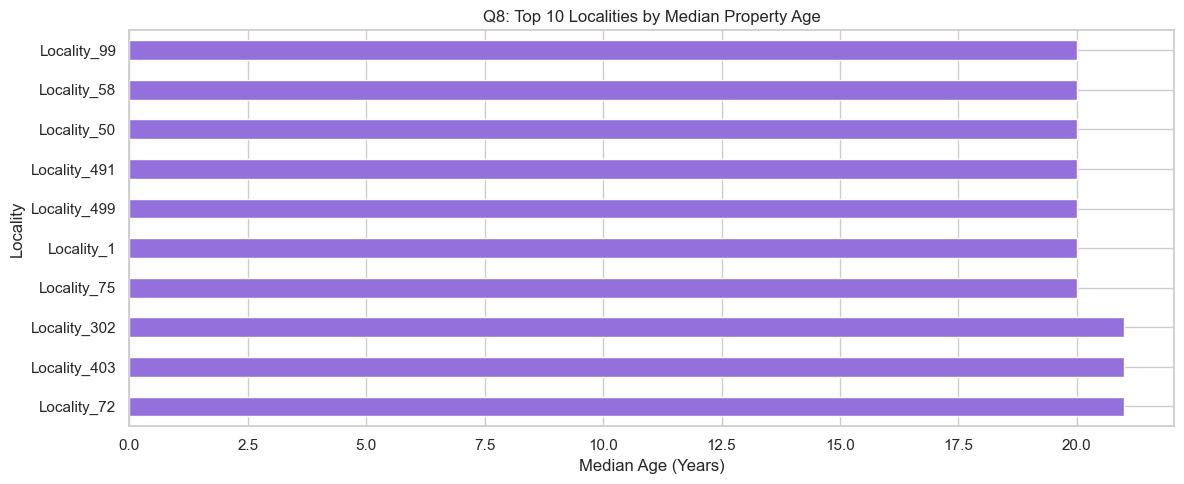

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
df.groupby('Locality')['Age_of_Property'].median().sort_values(ascending=False).head(10).plot(
    kind='barh', ax=ax, color='mediumpurple'
)
ax.set_title('Q8: Top 10 Localities by Median Property Age')
ax.set_xlabel('Median Age (Years)')
plt.tight_layout(); 
plt.show()

Q9: BHK distribution across Top 10 Cities

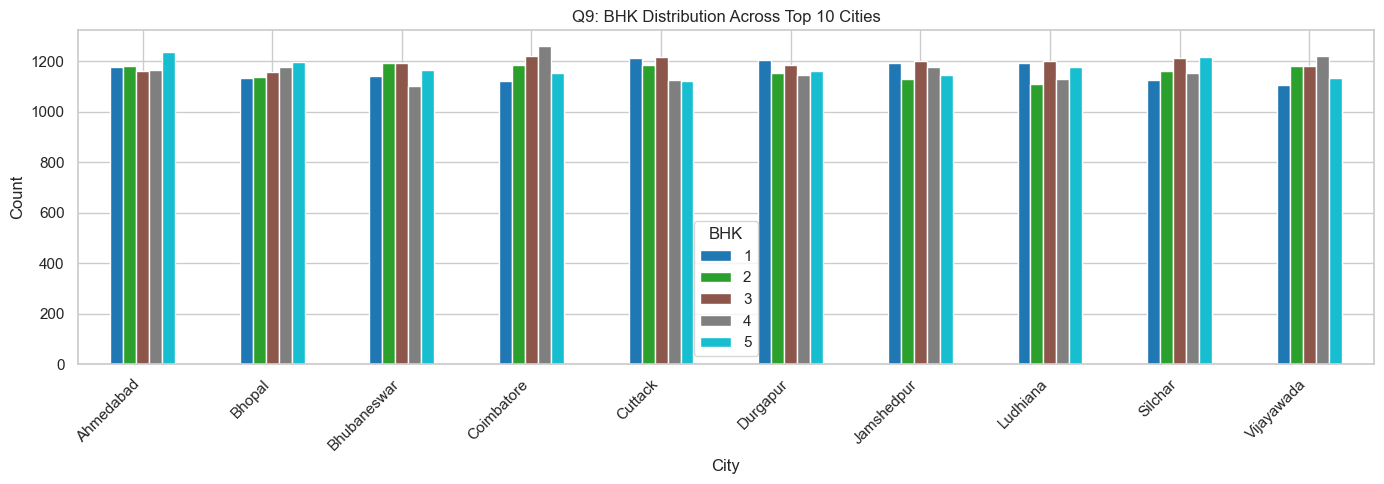

In [32]:
top_cities = df['City'].value_counts().head(10).index
city_bhk = df[df['City'].isin(top_cities)]
fig, ax = plt.subplots(figsize=(14, 5))
city_bhk.groupby(['City', 'BHK']).size().unstack().plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Q9: BHK Distribution Across Top 10 Cities')
ax.set_xlabel('City'); 
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right'); 
plt.tight_layout(); 
plt.show()

Q10: Price trends for Top 5 most expensive localities

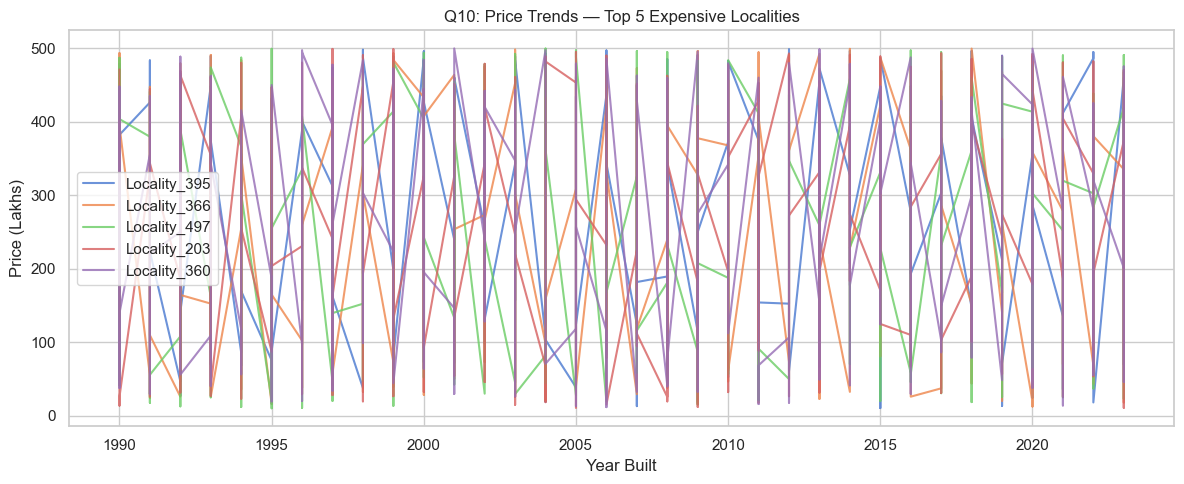

In [33]:
top5_loc = df.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5).index
fig, ax = plt.subplots(figsize=(12, 5))
for loc in top5_loc:
    sub = df[df['Locality'] == loc].sort_values('Year_Built')
    ax.plot(sub['Year_Built'], sub['Price_in_Lakhs'], label=loc, alpha=0.8)
ax.set_title('Q10: Price Trends — Top 5 Expensive Localities')
ax.set_xlabel('Year Built'); 
ax.set_ylabel('Price (Lakhs)')
ax.legend(); 
plt.tight_layout(); 
plt.show()

Q11: Correlation Heatmap

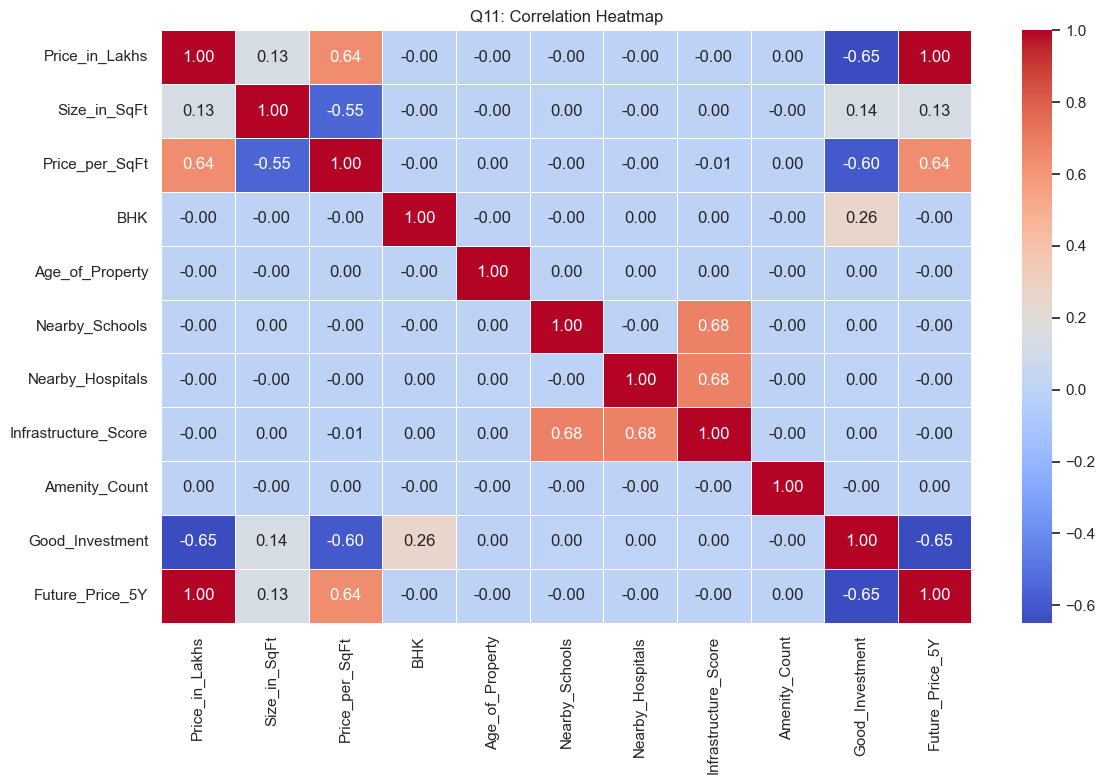

In [34]:
num_features = ['Price_in_Lakhs','Size_in_SqFt','Price_per_SqFt','BHK',
                'Age_of_Property','Nearby_Schools','Nearby_Hospitals',
                'Infrastructure_Score','Amenity_Count','Good_Investment','Future_Price_5Y']
existing = [c for c in num_features if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[existing].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Q11: Correlation Heatmap')
plt.tight_layout(); 
plt.show()

Q12 & Q13: Nearby Schools/Hospitals vs Price/SqFt

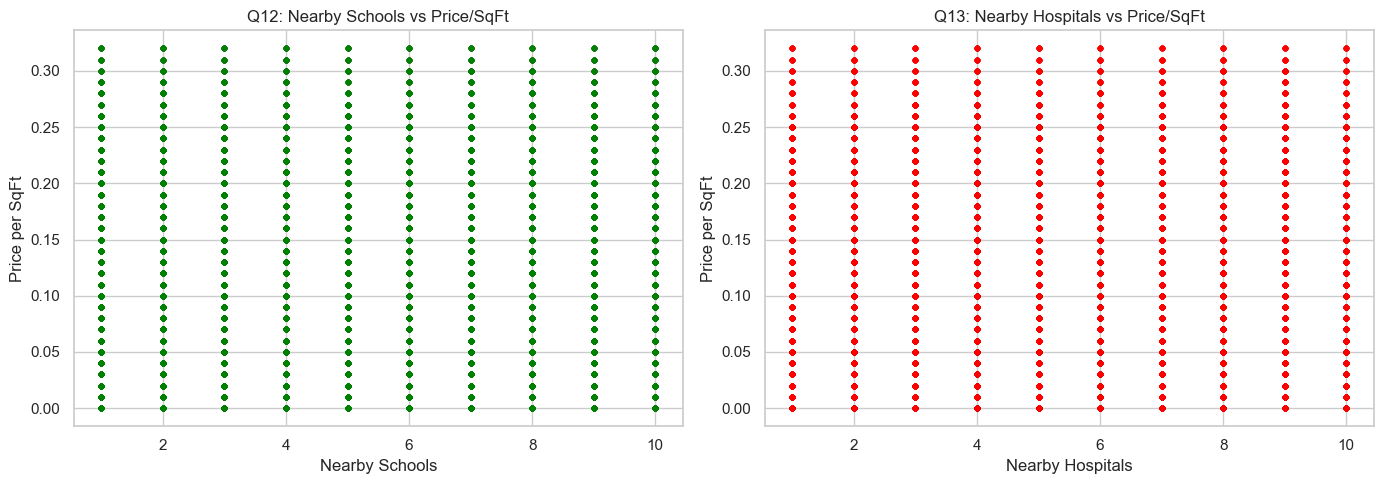

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['Nearby_Schools'], df['Price_per_SqFt'], alpha=0.3, color='green', s=8)
axes[0].set_title('Q12: Nearby Schools vs Price/SqFt')
axes[0].set_xlabel('Nearby Schools'); 
axes[0].set_ylabel('Price per SqFt')

axes[1].scatter(df['Nearby_Hospitals'], df['Price_per_SqFt'], alpha=0.3, color='red', s=8)
axes[1].set_title('Q13: Nearby Hospitals vs Price/SqFt')
axes[1].set_xlabel('Nearby Hospitals'); 
axes[1].set_ylabel('Price per SqFt')
plt.tight_layout(); 
plt.show()

Q14: Price by Furnished Status

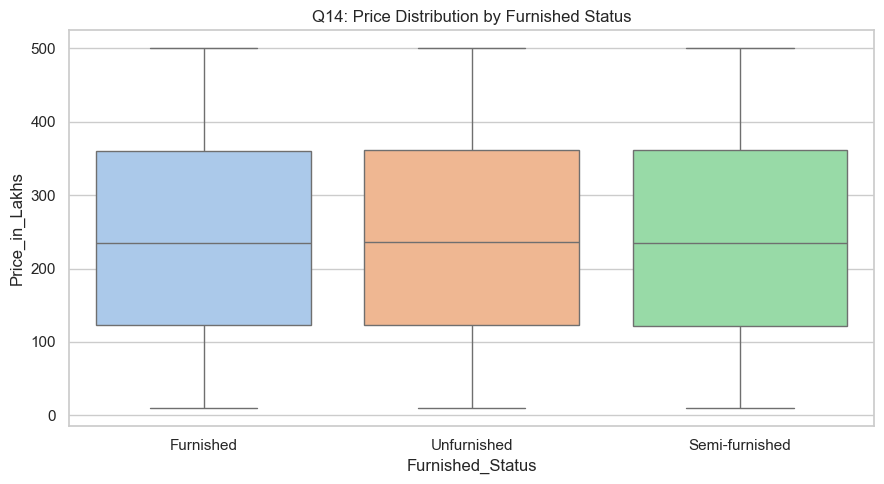

In [36]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Furnished_Status', y='Price_in_Lakhs', palette='pastel', ax=ax)
ax.set_title('Q14: Price Distribution by Furnished Status')
plt.tight_layout(); 
plt.show()

Q15: Price/SqFt by Facing Direction

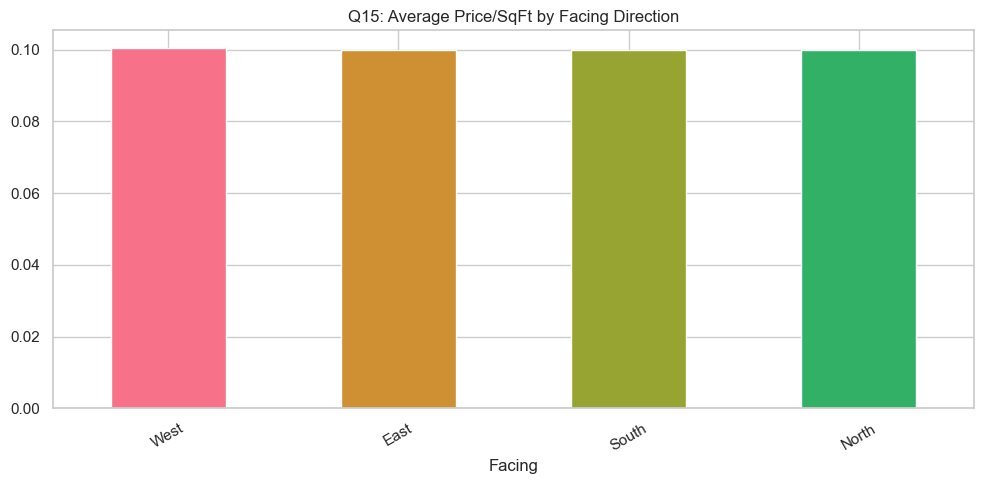

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('Facing')['Price_per_SqFt'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=sns.color_palette('husl', 8)
)
ax.set_title('Q15: Average Price/SqFt by Facing Direction')
plt.xticks(rotation=30); 
plt.tight_layout(); 
plt.show()

Q16: Owner Type Distribution

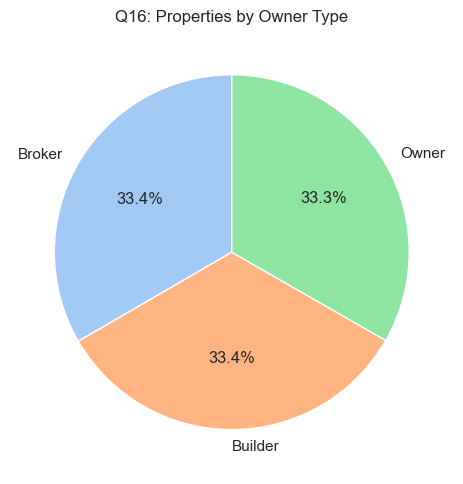

In [38]:
fig, ax = plt.subplots(figsize=(7, 5))
df['Owner_Type'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%',
                                      startangle=90, colors=sns.color_palette('pastel'))
ax.set_title('Q16: Properties by Owner Type'); 
ax.set_ylabel('')
plt.tight_layout(); 
plt.show()

Q17: Availability Status

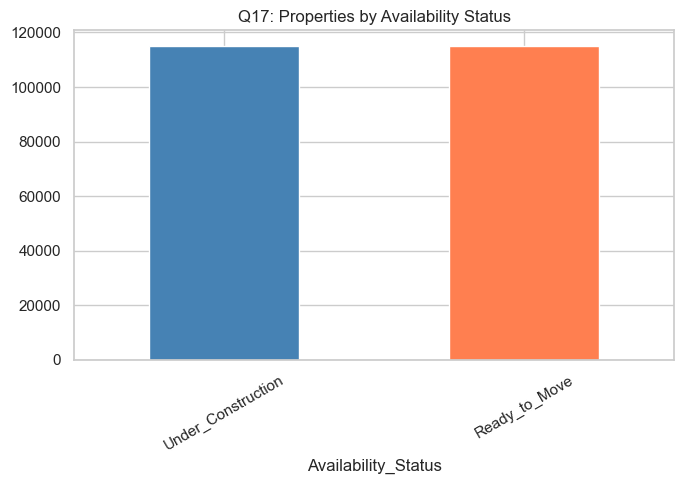

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
df['Availability_Status'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','coral','green'])
ax.set_title('Q17: Properties by Availability Status')
plt.xticks(rotation=30); 
plt.tight_layout(); 
plt.show()

Q18: Parking vs Price

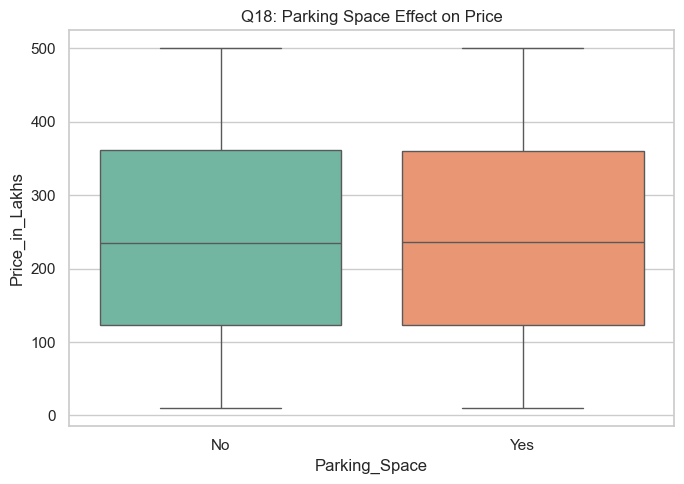

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='Parking_Space', y='Price_in_Lakhs', palette='Set2', ax=ax)
ax.set_title('Q18: Parking Space Effect on Price')
plt.tight_layout(); 
plt.show()

Q19: Amenity Count vs Price/SqFt

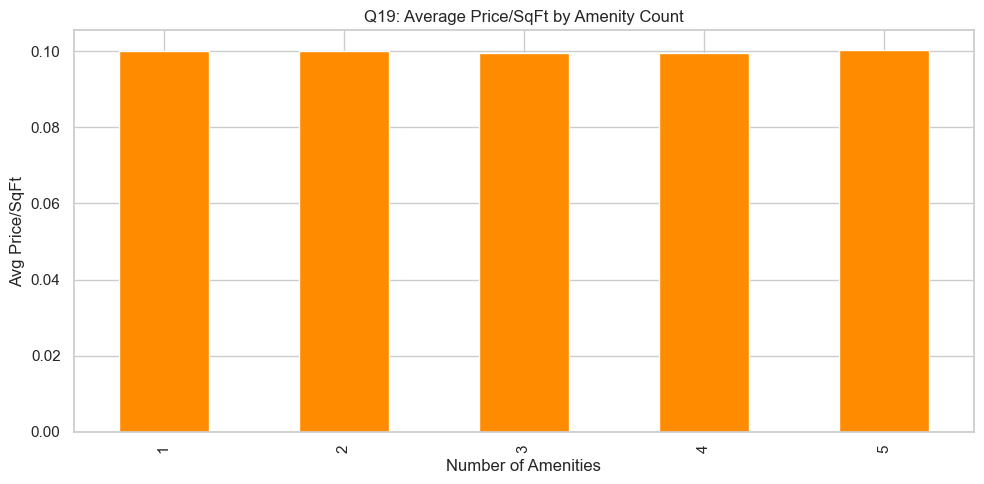

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('Amenity_Count')['Price_per_SqFt'].mean().plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Q19: Average Price/SqFt by Amenity Count')
ax.set_xlabel('Number of Amenities'); 
ax.set_ylabel('Avg Price/SqFt')
plt.tight_layout(); 
plt.show()

Q20: Public Transport Accessibility vs Price/SqFt

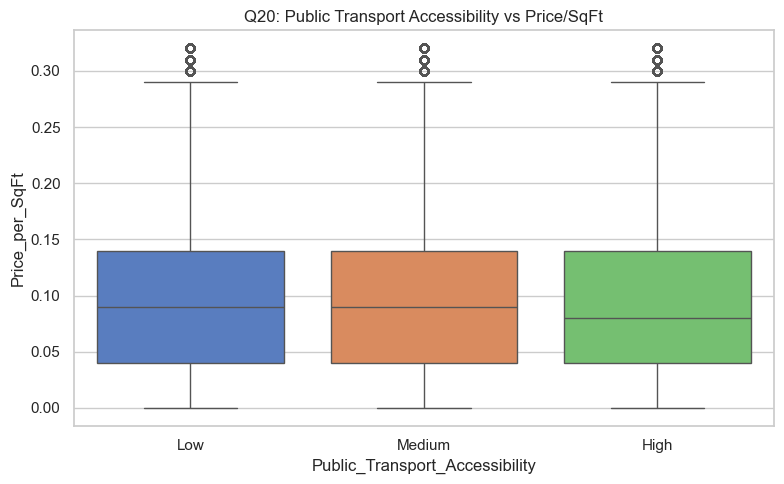

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Public_Transport_Accessibility', y='Price_per_SqFt',
            palette='muted', order=['Low','Medium','High'], ax=ax)
ax.set_title('Q20: Public Transport Accessibility vs Price/SqFt')
plt.tight_layout(); 
plt.show()

Prepare Features for Modeling

In [43]:
FEATURES = [
    'BHK', 'Size_in_SqFt', 'Price_per_SqFt', 'Age_of_Property',
    'Floor_No', 'Total_Floors', 'Nearby_Schools', 'Nearby_Hospitals',
    'Amenity_Count', 'Infrastructure_Score', 'Has_Parking', 'Has_Security',
    'Floor_Ratio', 'Transport_Score',
    'Furnished_Status_Enc', 'Facing_Enc', 'Owner_Type_Enc',
    'Availability_Status_Enc', 'Property_Type_Enc',
    'State_Enc', 'City_Enc'
]
FEATURES = [f for f in FEATURES if f in df.columns]

X      = df[FEATURES].copy()
y_clf  = df['Good_Investment'].copy()
y_reg  = df['Future_Price_5Y'].copy()

Train test split

In [44]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

Scale

In [45]:
scaler = StandardScaler()
X_train_c_sc = scaler.fit_transform(X_train_c)
X_test_c_sc  = scaler.transform(X_test_c)
X_train_r_sc = scaler.fit_transform(X_train_r)
X_test_r_sc  = scaler.transform(X_test_r)

print(f'Features: {len(FEATURES)}')
print(f'Train: {X_train_c.shape}, Test: {X_test_c.shape}')

Features: 21
Train: (183984, 21), Test: (45996, 21)


Classification Models

In [46]:
clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

uses_scaler_clf = {'Logistic Regression', 'KNN'}
clf_results = []

In [47]:
for name, model in clf_models.items():
    Xtr = X_train_c_sc if name in uses_scaler_clf else X_train_c
    Xte = X_test_c_sc  if name in uses_scaler_clf else X_test_c
    model.fit(Xtr, y_train_c)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    clf_results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test_c, y_pred),
        'Precision': precision_score(y_test_c, y_pred, zero_division=0),
        'Recall':    recall_score(y_test_c, y_pred, zero_division=0),
        'F1':        f1_score(y_test_c, y_pred, zero_division=0),
        'ROC_AUC':   roc_auc_score(y_test_c, y_prob)
    })
    print(f'{name}: Acc={accuracy_score(y_test_c, y_pred):.4f}')

clf_df = pd.DataFrame(clf_results).sort_values('ROC_AUC', ascending=False)
clf_df

Logistic Regression: Acc=0.8879
Decision Tree: Acc=0.9872
Random Forest: Acc=0.9905
Gradient Boosting: Acc=0.9909
KNN: Acc=0.8138
XGBoost: Acc=0.9902


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.990869,0.983853,0.989901,0.986868,0.999725
5,XGBoost,0.990238,0.984368,0.987517,0.985940,0.999718
2,Random Forest,0.990521,0.984744,0.987956,0.986348,0.999496
1,Decision Tree,0.987173,0.981616,0.981370,0.981493,0.985810
0,Logistic Regression,0.887947,0.842129,0.832832,0.837454,0.962661
4,KNN,0.813766,0.747517,0.698658,0.722262,0.876862


Classification Comparison Plot

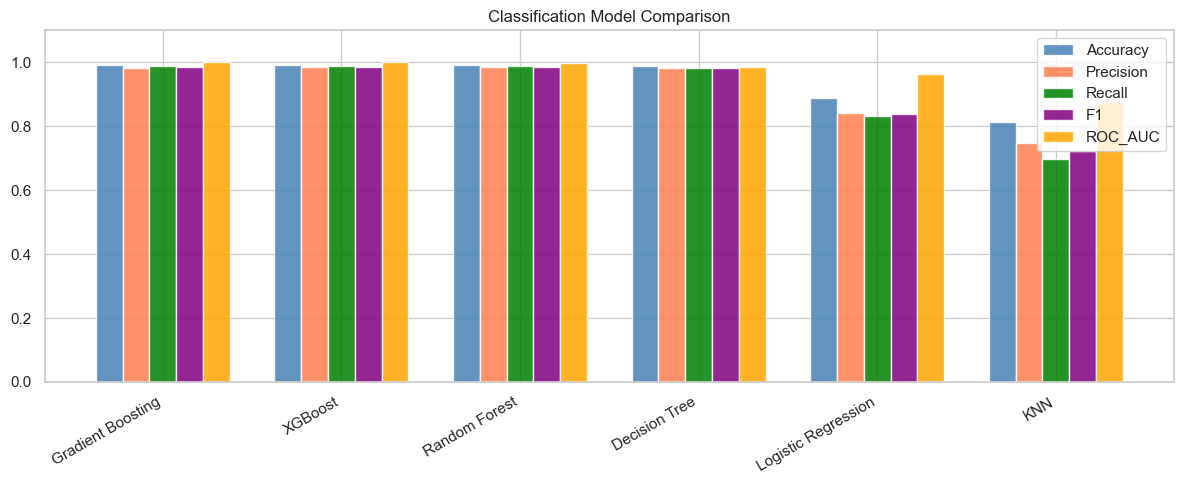

In [48]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(clf_df))
width = 0.15
for i, (metric, color) in enumerate(zip(
    ['Accuracy','Precision','Recall','F1','ROC_AUC'],
    ['steelblue','coral','green','purple','orange']
)):
    ax.bar(x + i * width, clf_df[metric], width, label=metric, color=color, alpha=0.85)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(clf_df['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Classification Model Comparison')
ax.legend()
plt.tight_layout(); 
plt.show()

Best model confusion matrix

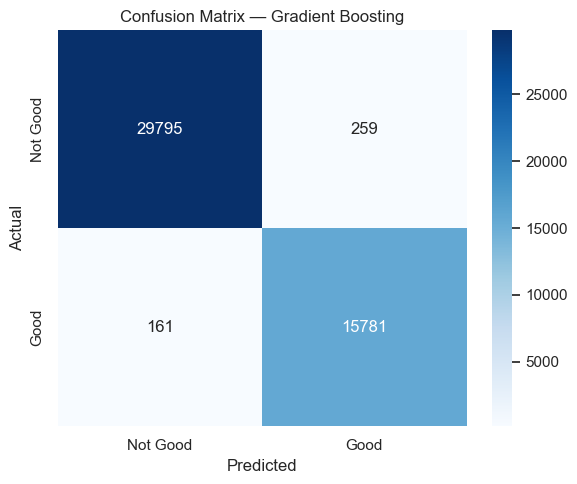

In [49]:
best_clf_name = clf_df.iloc[0]['Model']
best_clf      = clf_models[best_clf_name]
Xte = X_test_c_sc if best_clf_name in uses_scaler_clf else X_test_c
y_pred_best = best_clf.predict(Xte)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Good','Good'], yticklabels=['Not Good','Good'])
ax.set_title(f'Confusion Matrix — {best_clf_name}')
ax.set_ylabel('Actual'); 
ax.set_xlabel('Predicted')
plt.tight_layout(); 
plt.show()

In [50]:
print(f'\nBest Classifier: {best_clf_name}')
print(classification_report(y_test_c, y_pred_best, target_names=['Not Good','Good Investment']))


Best Classifier: Gradient Boosting
                 precision    recall  f1-score   support

       Not Good       0.99      0.99      0.99     30054
Good Investment       0.98      0.99      0.99     15942

       accuracy                           0.99     45996
      macro avg       0.99      0.99      0.99     45996
   weighted avg       0.99      0.99      0.99     45996



Regression Models

In [51]:
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

uses_scaler_reg = {'Linear Regression', 'Ridge Regression'}
reg_results = []

In [52]:
for name, model in reg_models.items():
    Xtr = X_train_r_sc if name in uses_scaler_reg else X_train_r
    Xte = X_test_r_sc  if name in uses_scaler_reg else X_test_r
    model.fit(Xtr, y_train_r)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae  = mean_absolute_error(y_test_r, y_pred)
    r2   = r2_score(y_test_r, y_pred)
    reg_results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    print(f'{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.4f}')

reg_df = pd.DataFrame(reg_results).sort_values('R2', ascending=False)
reg_df

Linear Regression: RMSE=105.10, MAE=82.55, R2=0.7379
Ridge Regression: RMSE=105.10, MAE=82.55, R2=0.7379
Decision Tree: RMSE=18.74, MAE=14.03, R2=0.9917
Random Forest: RMSE=13.55, MAE=10.70, R2=0.9956
Gradient Boosting: RMSE=20.43, MAE=16.63, R2=0.9901
XGBoost: RMSE=13.68, MAE=10.90, R2=0.9956


,Model,RMSE,MAE,R2
3,Random Forest,13.549206,10.696823,0.995645
5,XGBoost,13.678982,10.899402,0.995561
2,Decision Tree,18.740051,14.031776,0.991668
4,Gradient Boosting,20.433029,16.629707,0.990095
1,Ridge Regression,105.101767,82.550985,0.737927
0,Linear Regression,105.101768,82.551069,0.737927


Regression comparison plot

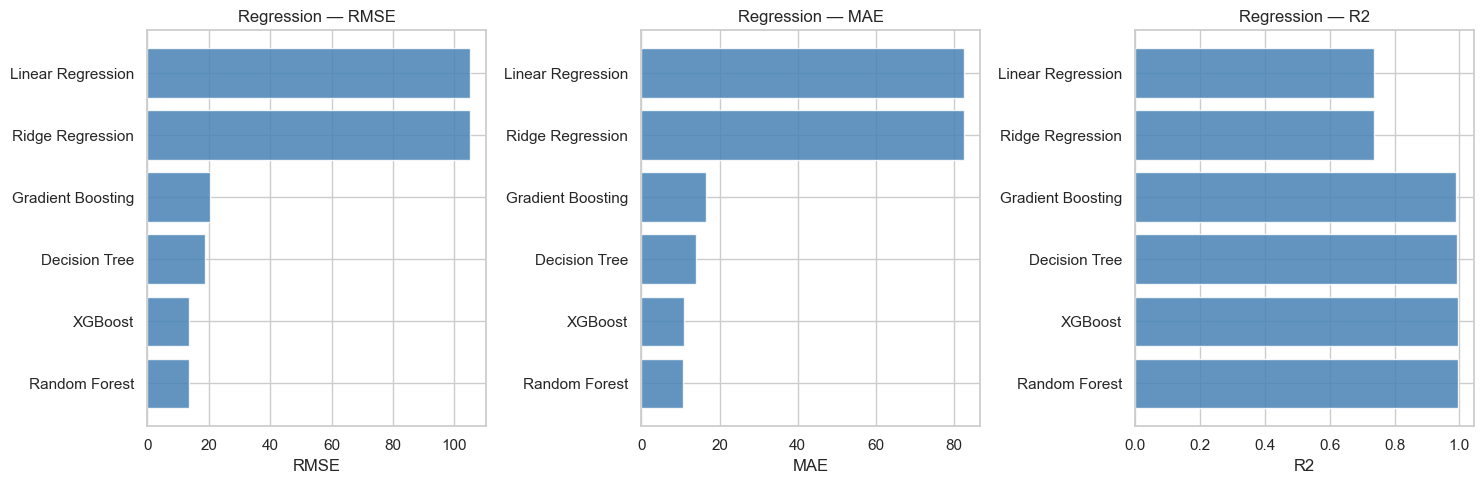

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['RMSE','MAE','R2']):
    temp = reg_df.sort_values(metric, ascending=(metric != 'R2'))
    ax.barh(temp['Model'], temp[metric], color='steelblue', alpha=0.85)
    ax.set_title(f'Regression — {metric}')
    ax.set_xlabel(metric)
plt.tight_layout(); 
plt.show()

Best regression model: Actual vs Predicted

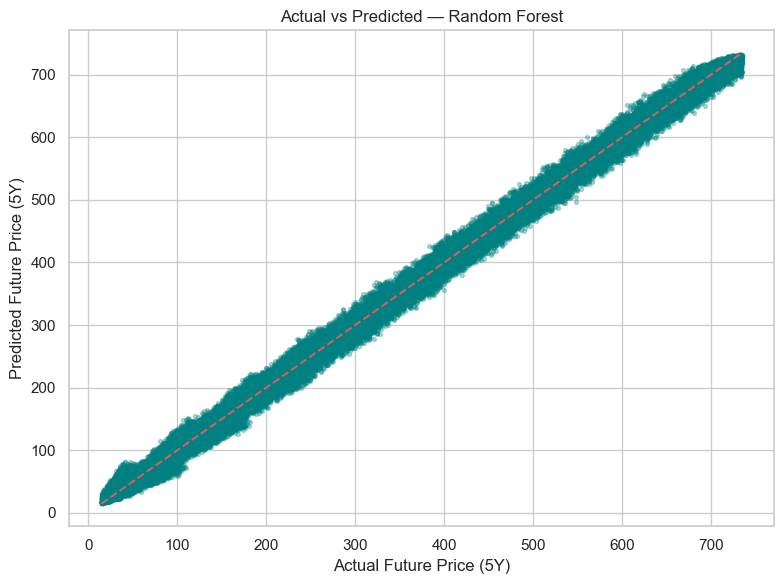

In [54]:
best_reg_name = reg_df.iloc[0]['Model']
best_reg      = reg_models[best_reg_name]
Xte_r = X_test_r_sc if best_reg_name in uses_scaler_reg else X_test_r
y_pred_reg = best_reg.predict(Xte_r)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_r, y_pred_reg, alpha=0.3, color='teal', s=8)
lims = [min(y_test_r.min(), y_pred_reg.min()), max(y_test_r.max(), y_pred_reg.max())]
ax.plot(lims, lims, 'r--', lw=1.5)
ax.set_title(f'Actual vs Predicted — {best_reg_name}')
ax.set_xlabel('Actual Future Price (5Y)'); ax.set_ylabel('Predicted Future Price (5Y)')
plt.tight_layout(); 
plt.show()

In [55]:
print(f'Best Regression Model: {best_reg_name}')

Best Regression Model: Random Forest


Feature Importance

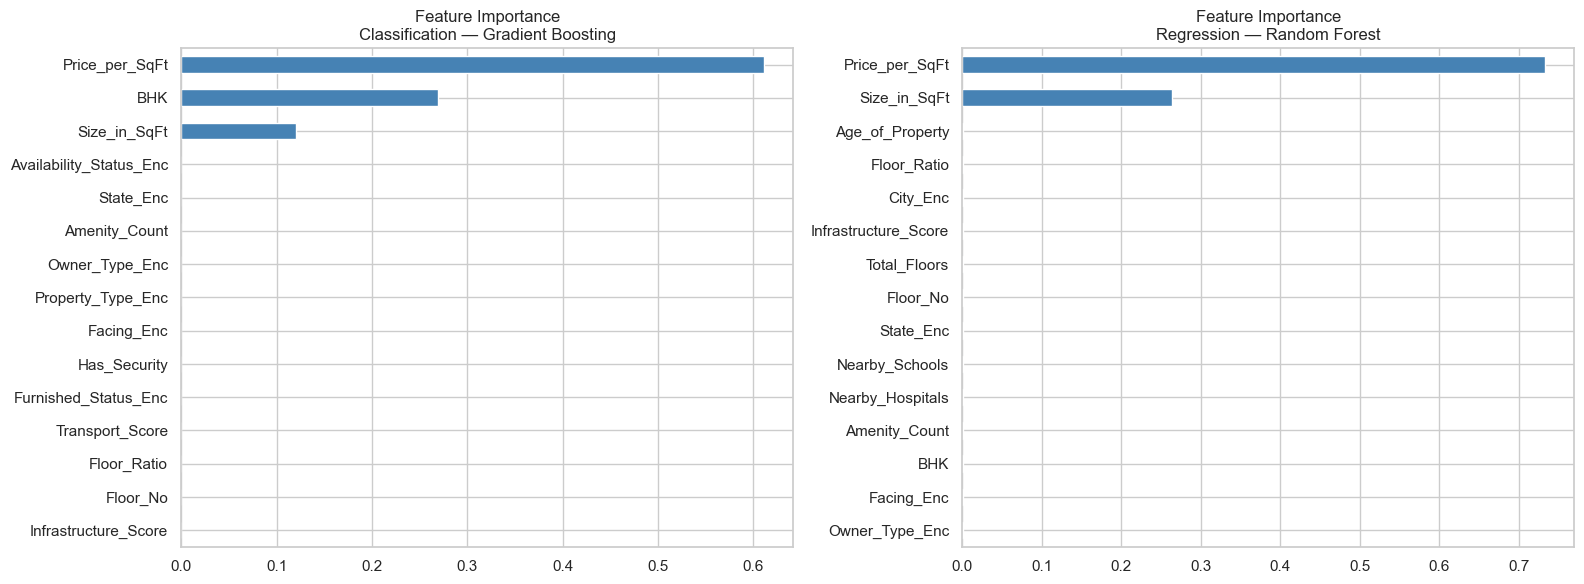

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, title in [
    (axes[0], best_clf, f'Classification — {best_clf_name}'),
    (axes[1], best_reg, f'Regression — {best_reg_name}')
]:
    try:
        imp = model.feature_importances_
        fi = pd.Series(imp, index=FEATURES).sort_values(ascending=True).tail(15)
        fi.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f'Feature Importance\n{title}')
    except AttributeError:
        ax.text(0.5, 0.5, 'Not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
plt.tight_layout(); 
plt.show()

MLflow Experiment Tracking

MLflow Classification

In [57]:
mlflow.set_tracking_uri('mlruns')

mlflow.set_experiment('Real_Estate_Classification')

for name, model in clf_models.items():
    with mlflow.start_run(run_name=name):
        Xte = X_test_c_sc if name in uses_scaler_clf else X_test_c
        Xtr = X_train_c_sc if name in uses_scaler_clf else X_train_c
        y_pred = model.predict(Xte)
        y_prob = model.predict_proba(Xte)[:, 1]

        mlflow.log_param('model_name', name)
        mlflow.log_metric('accuracy',  accuracy_score(y_test_c, y_pred))
        mlflow.log_metric('precision', precision_score(y_test_c, y_pred, zero_division=0))
        mlflow.log_metric('recall',    recall_score(y_test_c, y_pred, zero_division=0))
        mlflow.log_metric('f1_score',  f1_score(y_test_c, y_pred, zero_division=0))
        mlflow.log_metric('roc_auc',   roc_auc_score(y_test_c, y_prob))

        sig = infer_signature(Xtr, model.predict(Xtr))
        if 'XGBoost' in name:
            mlflow.xgboost.log_model(model, 'model', signature=sig)
        else:
            mlflow.sklearn.log_model(model, 'model', signature=sig)
        print(f'[CLF] Logged: {name}')

print('Classification experiments logged!')

2026/03/14 18:03:40 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Classification' does not exist. Creating a new experiment.


2026/03/14 18:03:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:03:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[CLF] Logged: Logistic Regression


2026/03/14 18:03:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:03:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[CLF] Logged: Decision Tree


...

[CLF] Logged: Gradient Boosting


2026/03/14 18:04:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:04:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[CLF] Logged: KNN


2026/03/14 18:04:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[CLF] Logged: XGBoost
Classification experiments logged!


MLflow Regression

In [58]:
mlflow.set_experiment('Real_Estate_Regression')

for name, model in reg_models.items():
    with mlflow.start_run(run_name=name):
        Xte = X_test_r_sc if name in uses_scaler_reg else X_test_r
        Xtr = X_train_r_sc if name in uses_scaler_reg else X_train_r
        y_pred = model.predict(Xte)

        mlflow.log_param('model_name', name)
        mlflow.log_metric('rmse', np.sqrt(mean_squared_error(y_test_r, y_pred)))
        mlflow.log_metric('mae',  mean_absolute_error(y_test_r, y_pred))
        mlflow.log_metric('r2',   r2_score(y_test_r, y_pred))

        sig = infer_signature(Xtr, model.predict(Xtr))
        if 'XGBoost' in name:
            mlflow.xgboost.log_model(model, 'model', signature=sig)
        else:
            mlflow.sklearn.log_model(model, 'model', signature=sig)
        print(f'[REG] Logged: {name}')

print('Regression experiments logged!')

2026/03/14 18:04:43 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Regression' does not exist. Creating a new experiment.
2026/03/14 18:04:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:04:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/14 18:04:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:04:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during d

[REG] Logged: Linear Regression
[REG] Logged: Ridge Regression


2026/03/14 18:04:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:04:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[REG] Logged: Decision Tree


2026/03/14 18:05:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:05:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[REG] Logged: Random Forest


2026/03/14 18:05:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 18:05:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[REG] Logged: Gradient Boosting


2026/03/14 18:05:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[REG] Logged: XGBoost
Regression experiments logged!


Save Best Models

In [59]:
os.makedirs('model', exist_ok=True)

In [60]:
joblib.dump(best_clf, 'model/best_classifier.pkl')
joblib.dump(best_reg, 'model/best_regressor.pkl')
joblib.dump(scaler,   'model/scaler.pkl')
joblib.dump(FEATURES, 'model/features.pkl')

['model/features.pkl']

Save label encoders

In [61]:
encoder_dict = {}
for col in ['Furnished_Status','Facing','Owner_Type','Availability_Status','Property_Type','State','City']:
    if col in df.columns:
        le_tmp = LabelEncoder()
        le_tmp.fit(df[col].astype(str))
        encoder_dict[col] = le_tmp
joblib.dump(encoder_dict, 'model/label_encoders.pkl')

['model/label_encoders.pkl']

Save unique values for dropdowns in Streamlit

In [62]:
meta = {
    'cities':               sorted(df['City'].unique().tolist()),
    'states':               sorted(df['State'].unique().tolist()),
    'property_types':       sorted(df['Property_Type'].unique().tolist()),
    'furnished_statuses':   sorted(df['Furnished_Status'].unique().tolist()),
    'facings':              sorted(df['Facing'].unique().tolist()),
    'owner_types':          sorted(df['Owner_Type'].unique().tolist()),
    'availability_statuses':sorted(df['Availability_Status'].unique().tolist()),
    'transport_options':    ['Low','Medium','High'],
    'best_clf_name':        best_clf_name,
    'best_reg_name':        best_reg_name,
    'features':             FEATURES
}
joblib.dump(meta, 'model/meta.pkl')

['model/meta.pkl']

Summary

In [63]:
print(f'\n Dataset Shape (after cleaning): {df.shape}')


 Dataset Shape (after cleaning): (229980, 38)


In [64]:
print(f'\n Best Classification Model : {best_clf_name}')
row = clf_df.iloc[0]
print(f'   Accuracy : {row["Accuracy"]:.4f}')
print(f'   F1 Score : {row["F1"]:.4f}')
print(f'   ROC AUC  : {row["ROC_AUC"]:.4f}')


 Best Classification Model : Gradient Boosting
   Accuracy : 0.9909
   F1 Score : 0.9869
   ROC AUC  : 0.9997


In [65]:
print(f'\n Best Regression Model : {best_reg_name}')
row2 = reg_df.iloc[0]
print(f'   RMSE : {row2["RMSE"]:.2f}')
print(f'   MAE  : {row2["MAE"]:.2f}')
print(f'   R2   : {row2["R2"]:.4f}')


 Best Regression Model : Random Forest
   RMSE : 13.55
   MAE  : 10.70
   R2   : 0.9956
